**Diffusion Models**

Resolving data files:   0%|          | 0/56398 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/7167 [00:00<?, ?it/s]

Computing checksums:  59%|#####8    | 33036/56398 [00:05<00:03, 6605.98it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

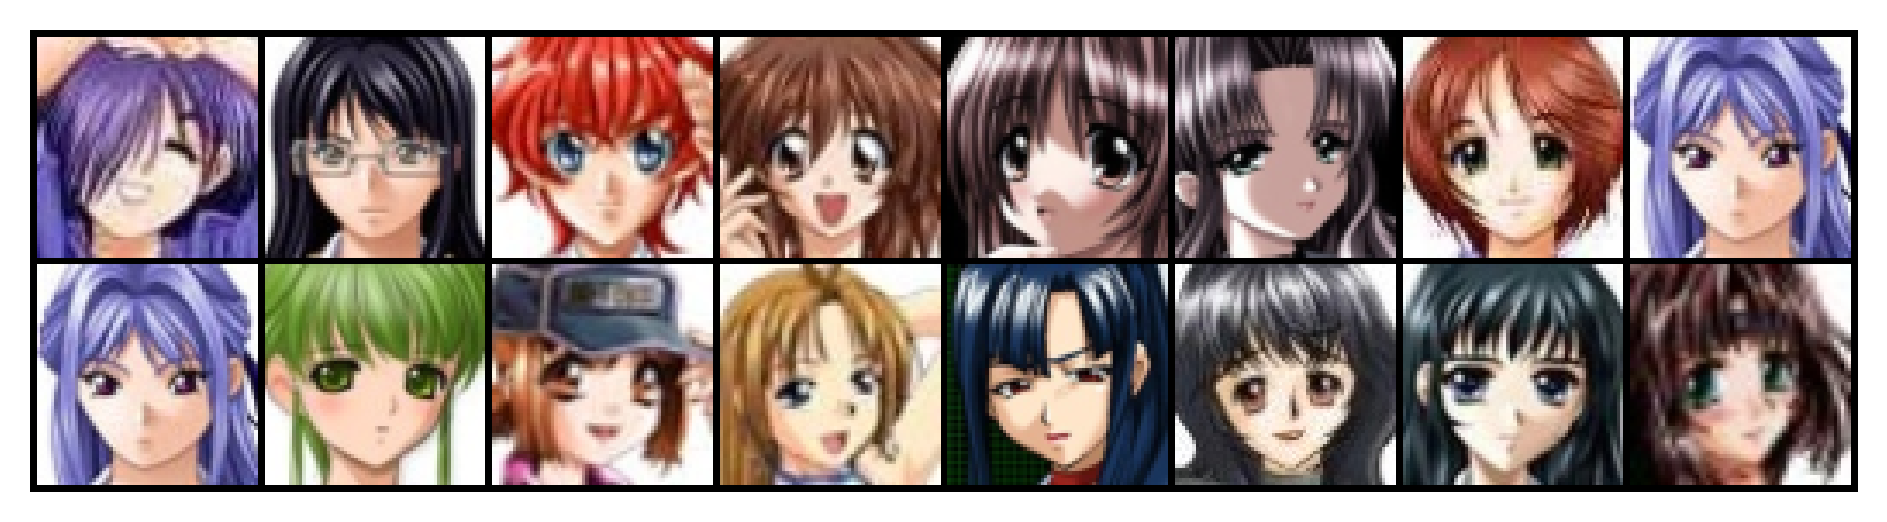

In [1]:
from datasets import load_dataset
from util import transforms

dataset = load_dataset(r"D:\DeepLearning\DataSet\Figure\animeface", split="test", )
dataset.set_transform(transforms)

import matplotlib.pyplot as plt
from torchvision.utils import make_grid

grid = make_grid(dataset[:16]["input"], 8, 2)
plt.figure(figsize=(8,2),dpi=300)
plt.imshow(grid.numpy().transpose((1,2,0)))
plt.axis("off")
plt.show()

In [2]:
import torch

import matplotlib.pyplot as plt
from torchvision.utils import make_grid

resolution=64
batch_size=4
train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True)

forward diffusion process

In [3]:
clean_images=next(iter(train_dataloader))["input"]*2-1
print(clean_images.shape)
nums=clean_images.shape[0]
noise=torch.randn(clean_images.shape)
print(noise.shape)

torch.Size([4, 3, 64, 64])
torch.Size([4, 3, 64, 64])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8758693..2.5392177].


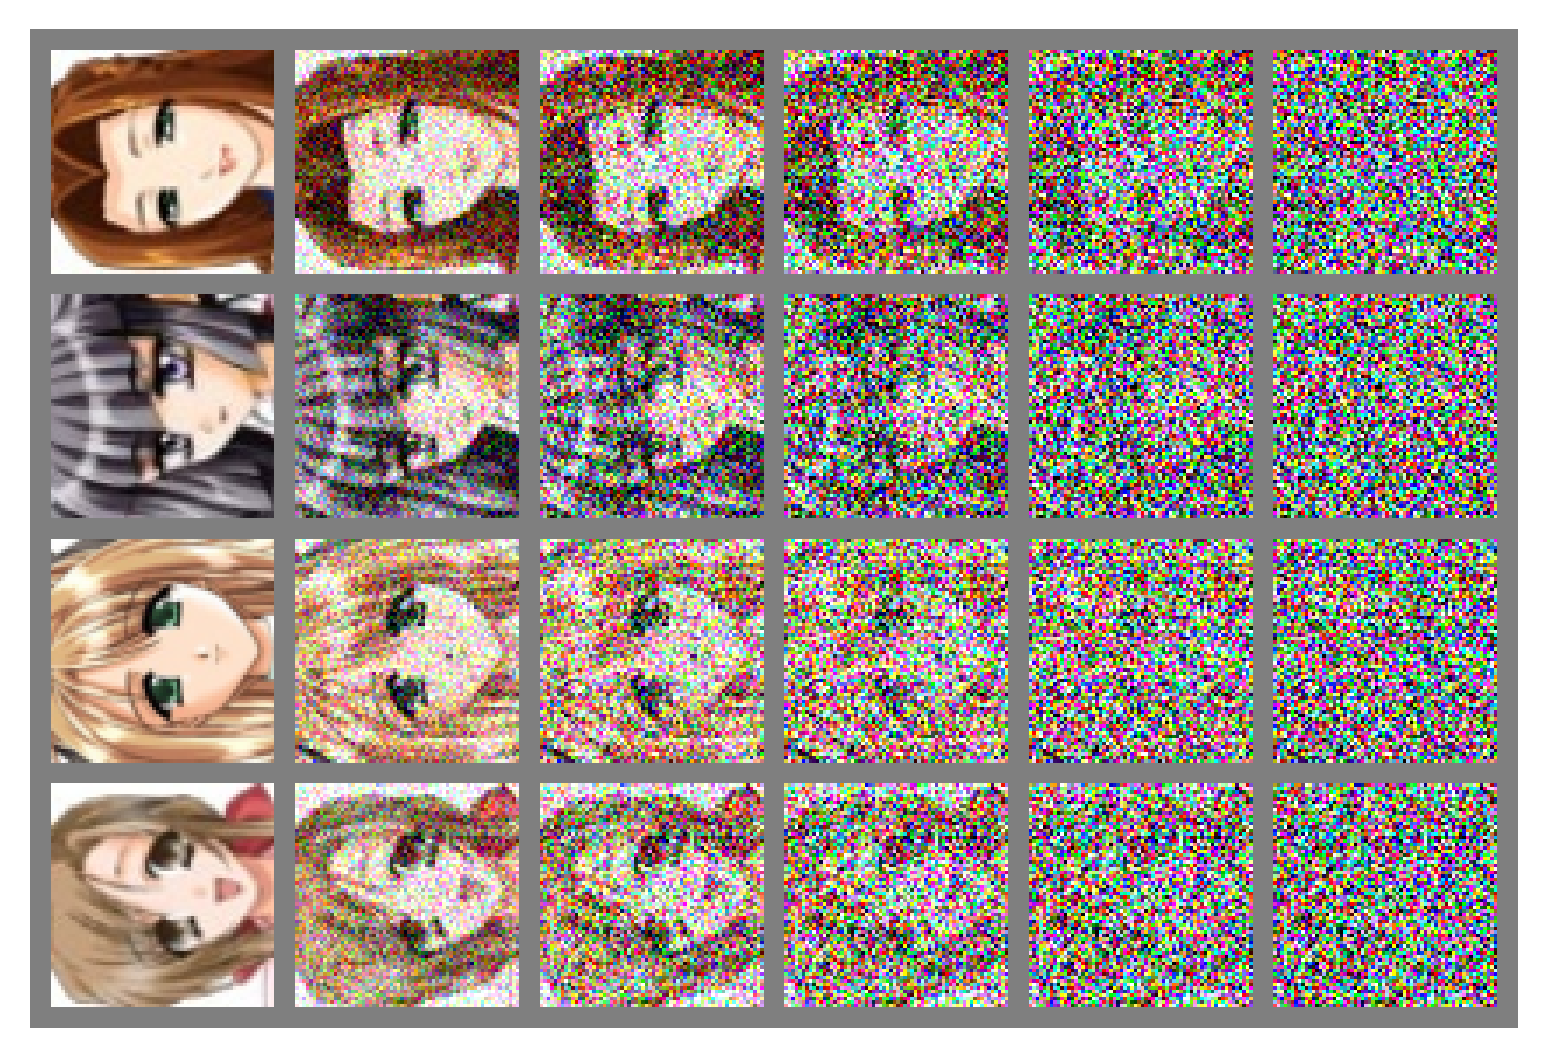

In [4]:
from util import DDIMScheduler

noise_scheduler=DDIMScheduler(num_train_timesteps=1000)
allimgs=clean_images
for step in range(200,1001,200):
    timesteps=torch.tensor([step-1]*4).long()
    noisy_images=noise_scheduler.add_noise(clean_images,
                 noise, timesteps)
    allimgs=torch.cat((allimgs,noisy_images))

import torchvision
imgs=torchvision.utils.make_grid(allimgs,4,6)
fig = plt.figure(dpi=300)
plt.imshow((imgs.permute(2,1,0)+1)/2)
plt.axis("off")
plt.show()

**Denoising U-Net Model**

In [5]:
import torch
from torch import nn, einsum
from einops import rearrange

class Attention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)
    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)    #A
        q, k, v = map(
        lambda t: rearrange(t, 'b (h c) x y -> b h c (x y)', h=self.heads),
        qkv)    #B
        q = q * self.scale    
        sim = einsum('b h d i, b h d j -> b h i j', q, k)
        attn = sim.softmax(dim=-1)    #C
        out = einsum('b h i j, b h d j -> b h i d', attn, v)    #D
        out = rearrange(out, 'b h (x y) d -> b (h d) x y', x=h, y=w)
        return self.to_out(out)    #E

attn=Attention(128)
x=torch.rand(1,128,64,64)
out=attn(x)
print(out.shape)

torch.Size([1, 128, 64, 64])


In [11]:
from unet_util import UNet

device="cuda" if torch.cuda.is_available() else "cpu"
resolution=64
model=UNet(3,hidden_dims=[128,256,512,1024],
           image_size=resolution).to(device)
num=sum(p.numel() for p in model.parameters())

print("number of parameters: %.2fM" % (num/1e6,))
print(model)

number of parameters: 133.42M
UNet(
  (time_embedding): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): SiLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
  )
  (init_conv): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down_blocks): ModuleList(
    (0): ModuleList(
      (0-1): 2 x ResidualBlock(
        (time_emb_proj): Sequential(
          (0): SiLU()
          (1): Linear(in_features=512, out_features=128, bias=True)
        )
        (residual_conv): Identity()
        (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
        (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
        (nonlinearity): SiLU()
      )
      (2): Identity()
      (3): Sequential(
        (0): Rearrange('b c (h p1) (w p2) -> b (c p1 p2) h w', p1=2, p2=2)
     

In [12]:
from diffusers.optimization import get_scheduler

num_epochs=100
optimizer=torch.optim.AdamW(model.parameters(),lr=0.0001,
    betas=(0.95,0.999),weight_decay=0.00001,eps=1e-8)
lr_scheduler=get_scheduler(
    "cosine",
    optimizer=optimizer,
    num_warmup_steps=300,
    num_training_steps=(len(train_dataloader) * num_epochs))

In [15]:
for epoch in range(num_epochs):
    model.train()
    tloss = 0
    print(f"start epoch {epoch}")
    for step, batch in enumerate(train_dataloader):
        clean_images = batch["input"].to(device)*2-1
        nums = clean_images.shape[0]
        noise = torch.randn(clean_images.shape).to(device)
        timesteps = torch.randint(0,
                noise_scheduler.num_train_timesteps,
                (nums, ),
                device=device).long()
        noisy_images = noise_scheduler.add_noise(clean_images,
                     noise, timesteps)

        noise_pred = model(noisy_images, timesteps)["sample"]
        loss = torch.nn.functional.l1_loss(noise_pred, noise)
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        tloss += loss.detach().item()
        if step%100==0:
            print(f"step {step}, average loss {tloss/(step+1)}")

torch.save(model.state_dict(), r"D:\DeepLearning\DataSet\Model-Weight\diffusion.pth")

start epoch 0
step 0, average loss 0.2899710536003113
step 100, average loss 0.23531184397121468
step 200, average loss 0.23075519924733176
step 300, average loss 0.22487294069952346
step 400, average loss 0.21987801786521427
step 500, average loss 0.21426442802368761
step 600, average loss 0.21070210252595623
step 700, average loss 0.20637977371967467
step 800, average loss 0.20271942525469558
step 900, average loss 0.19918542297414352
step 1000, average loss 0.1973615724455703
step 1100, average loss 0.19385414383121233
step 1200, average loss 0.1926110145960819
step 1300, average loss 0.1903175126294463
step 1400, average loss 0.18826939994143554
step 1500, average loss 0.1866653378132103
step 1600, average loss 0.18565286148681556
step 1700, average loss 0.18428672998617987
start epoch 1
step 0, average loss 0.1116299033164978
step 100, average loss 0.16409564748553945
step 200, average loss 0.16047500974651593
step 300, average loss 0.15987428054956107
step 400, average loss 0.159

100%|██████████| 50/50 [00:56<00:00,  1.13s/it]


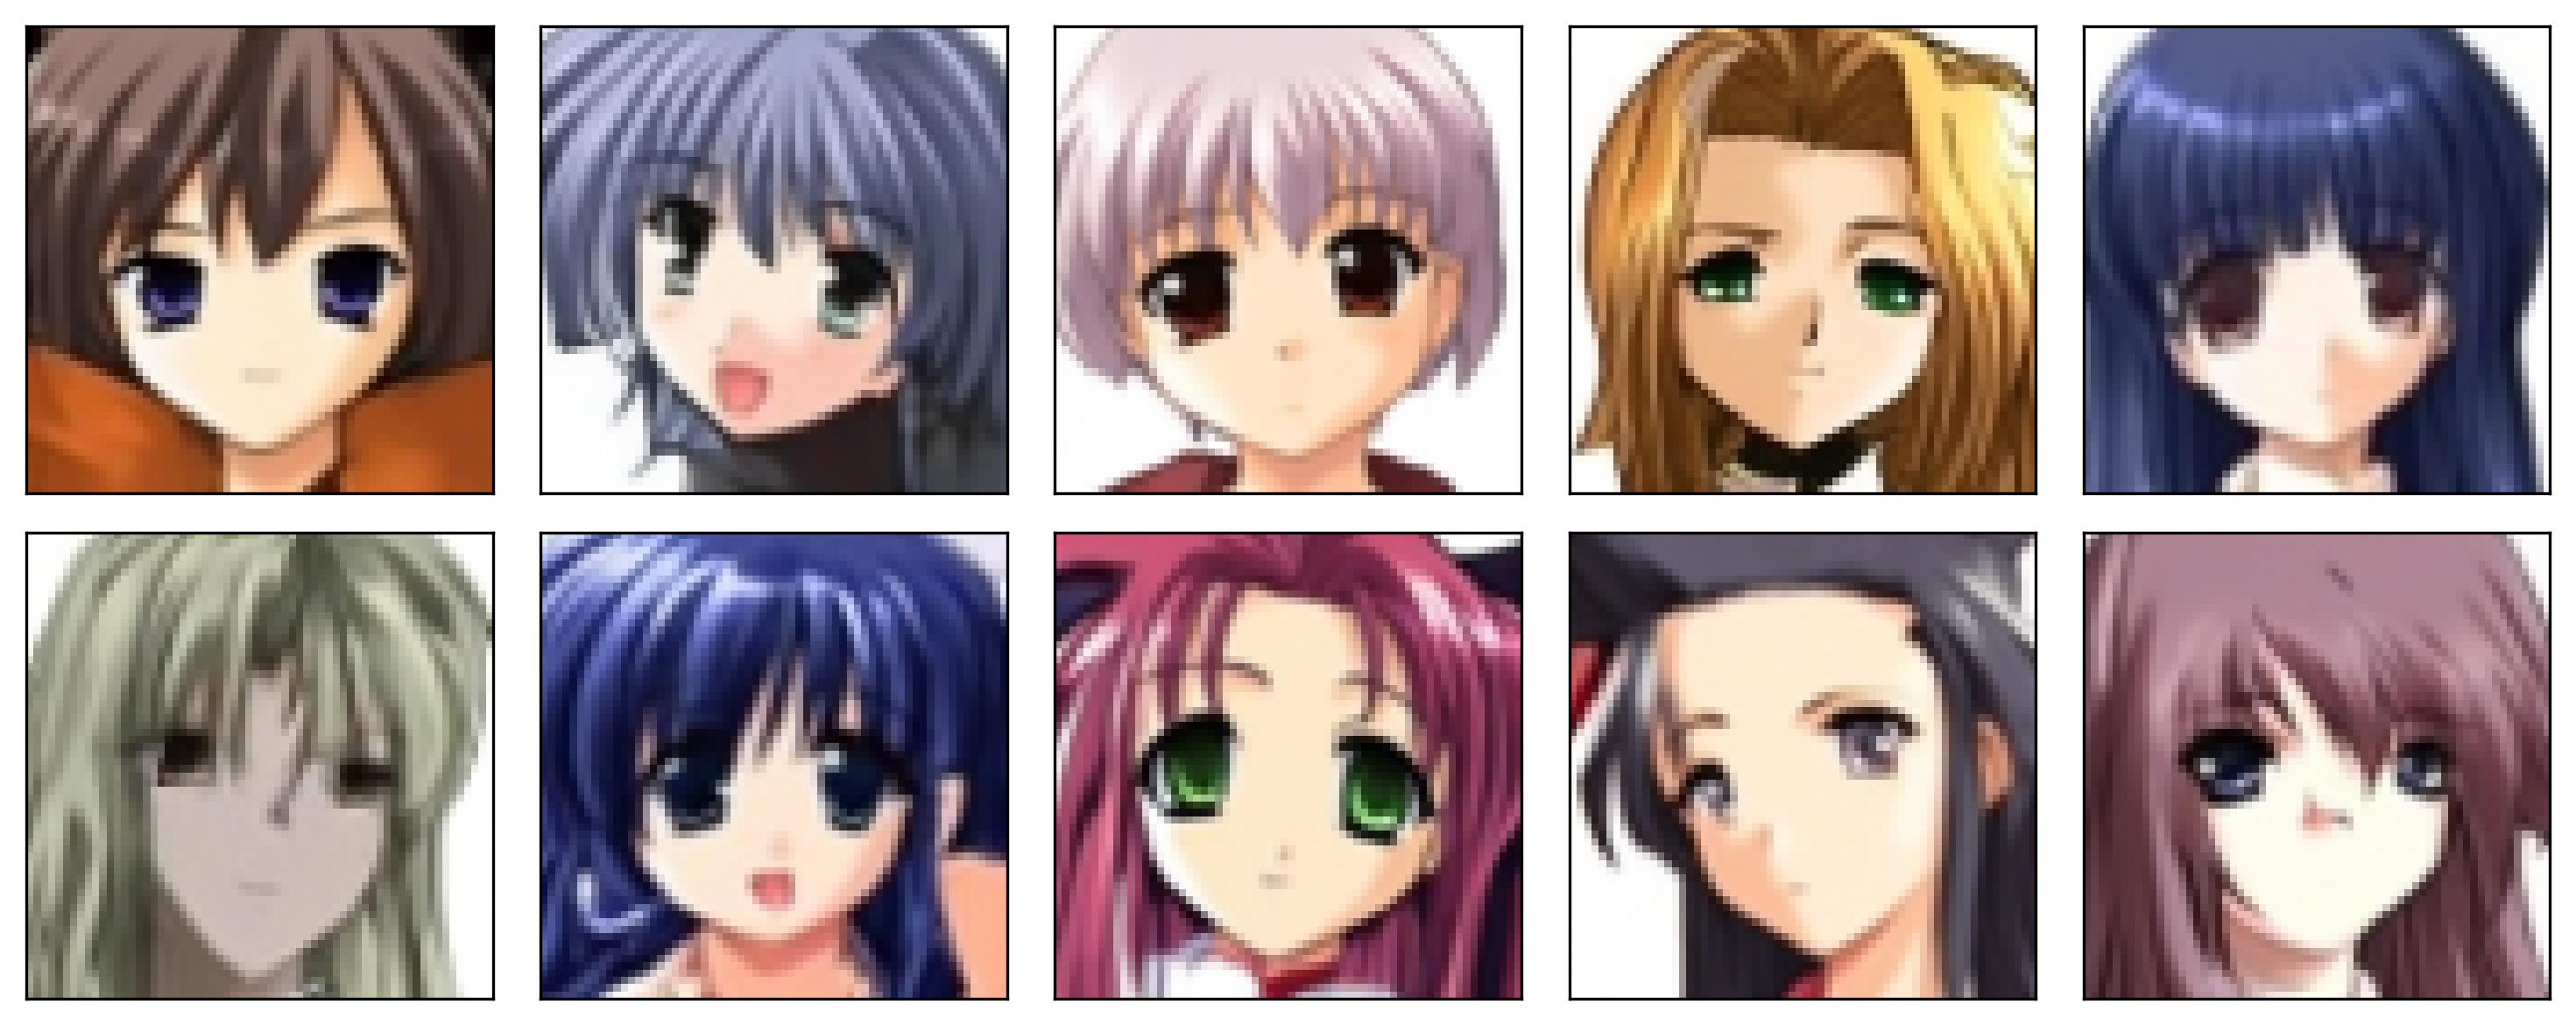

In [16]:
import matplotlib.pyplot as plt

sd=torch.load(r"D:\DeepLearning\DataSet\Model-Weight\diffusion.pth")
model.load_state_dict(sd)
with torch.no_grad():
    generator = torch.manual_seed(1)
    generated_images,imgs = noise_scheduler.generate(
        model,device,
        num_inference_steps=50,
        generator=generator,
        eta=1.0,
        use_clipped_model_output=True,
        batch_size=10)
imgnp=generated_images["sample"]    

plt.figure(figsize=(10,4),dpi=300)
for i in range(10):
    ax = plt.subplot(2,5, i + 1)
    plt.imshow(imgnp[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.49487..2.2162633].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3661454..2.2497292].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7099446..2.0729313].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.32696897..1.455111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3036911..2.4020317].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1000276..2.309854].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.727636..1

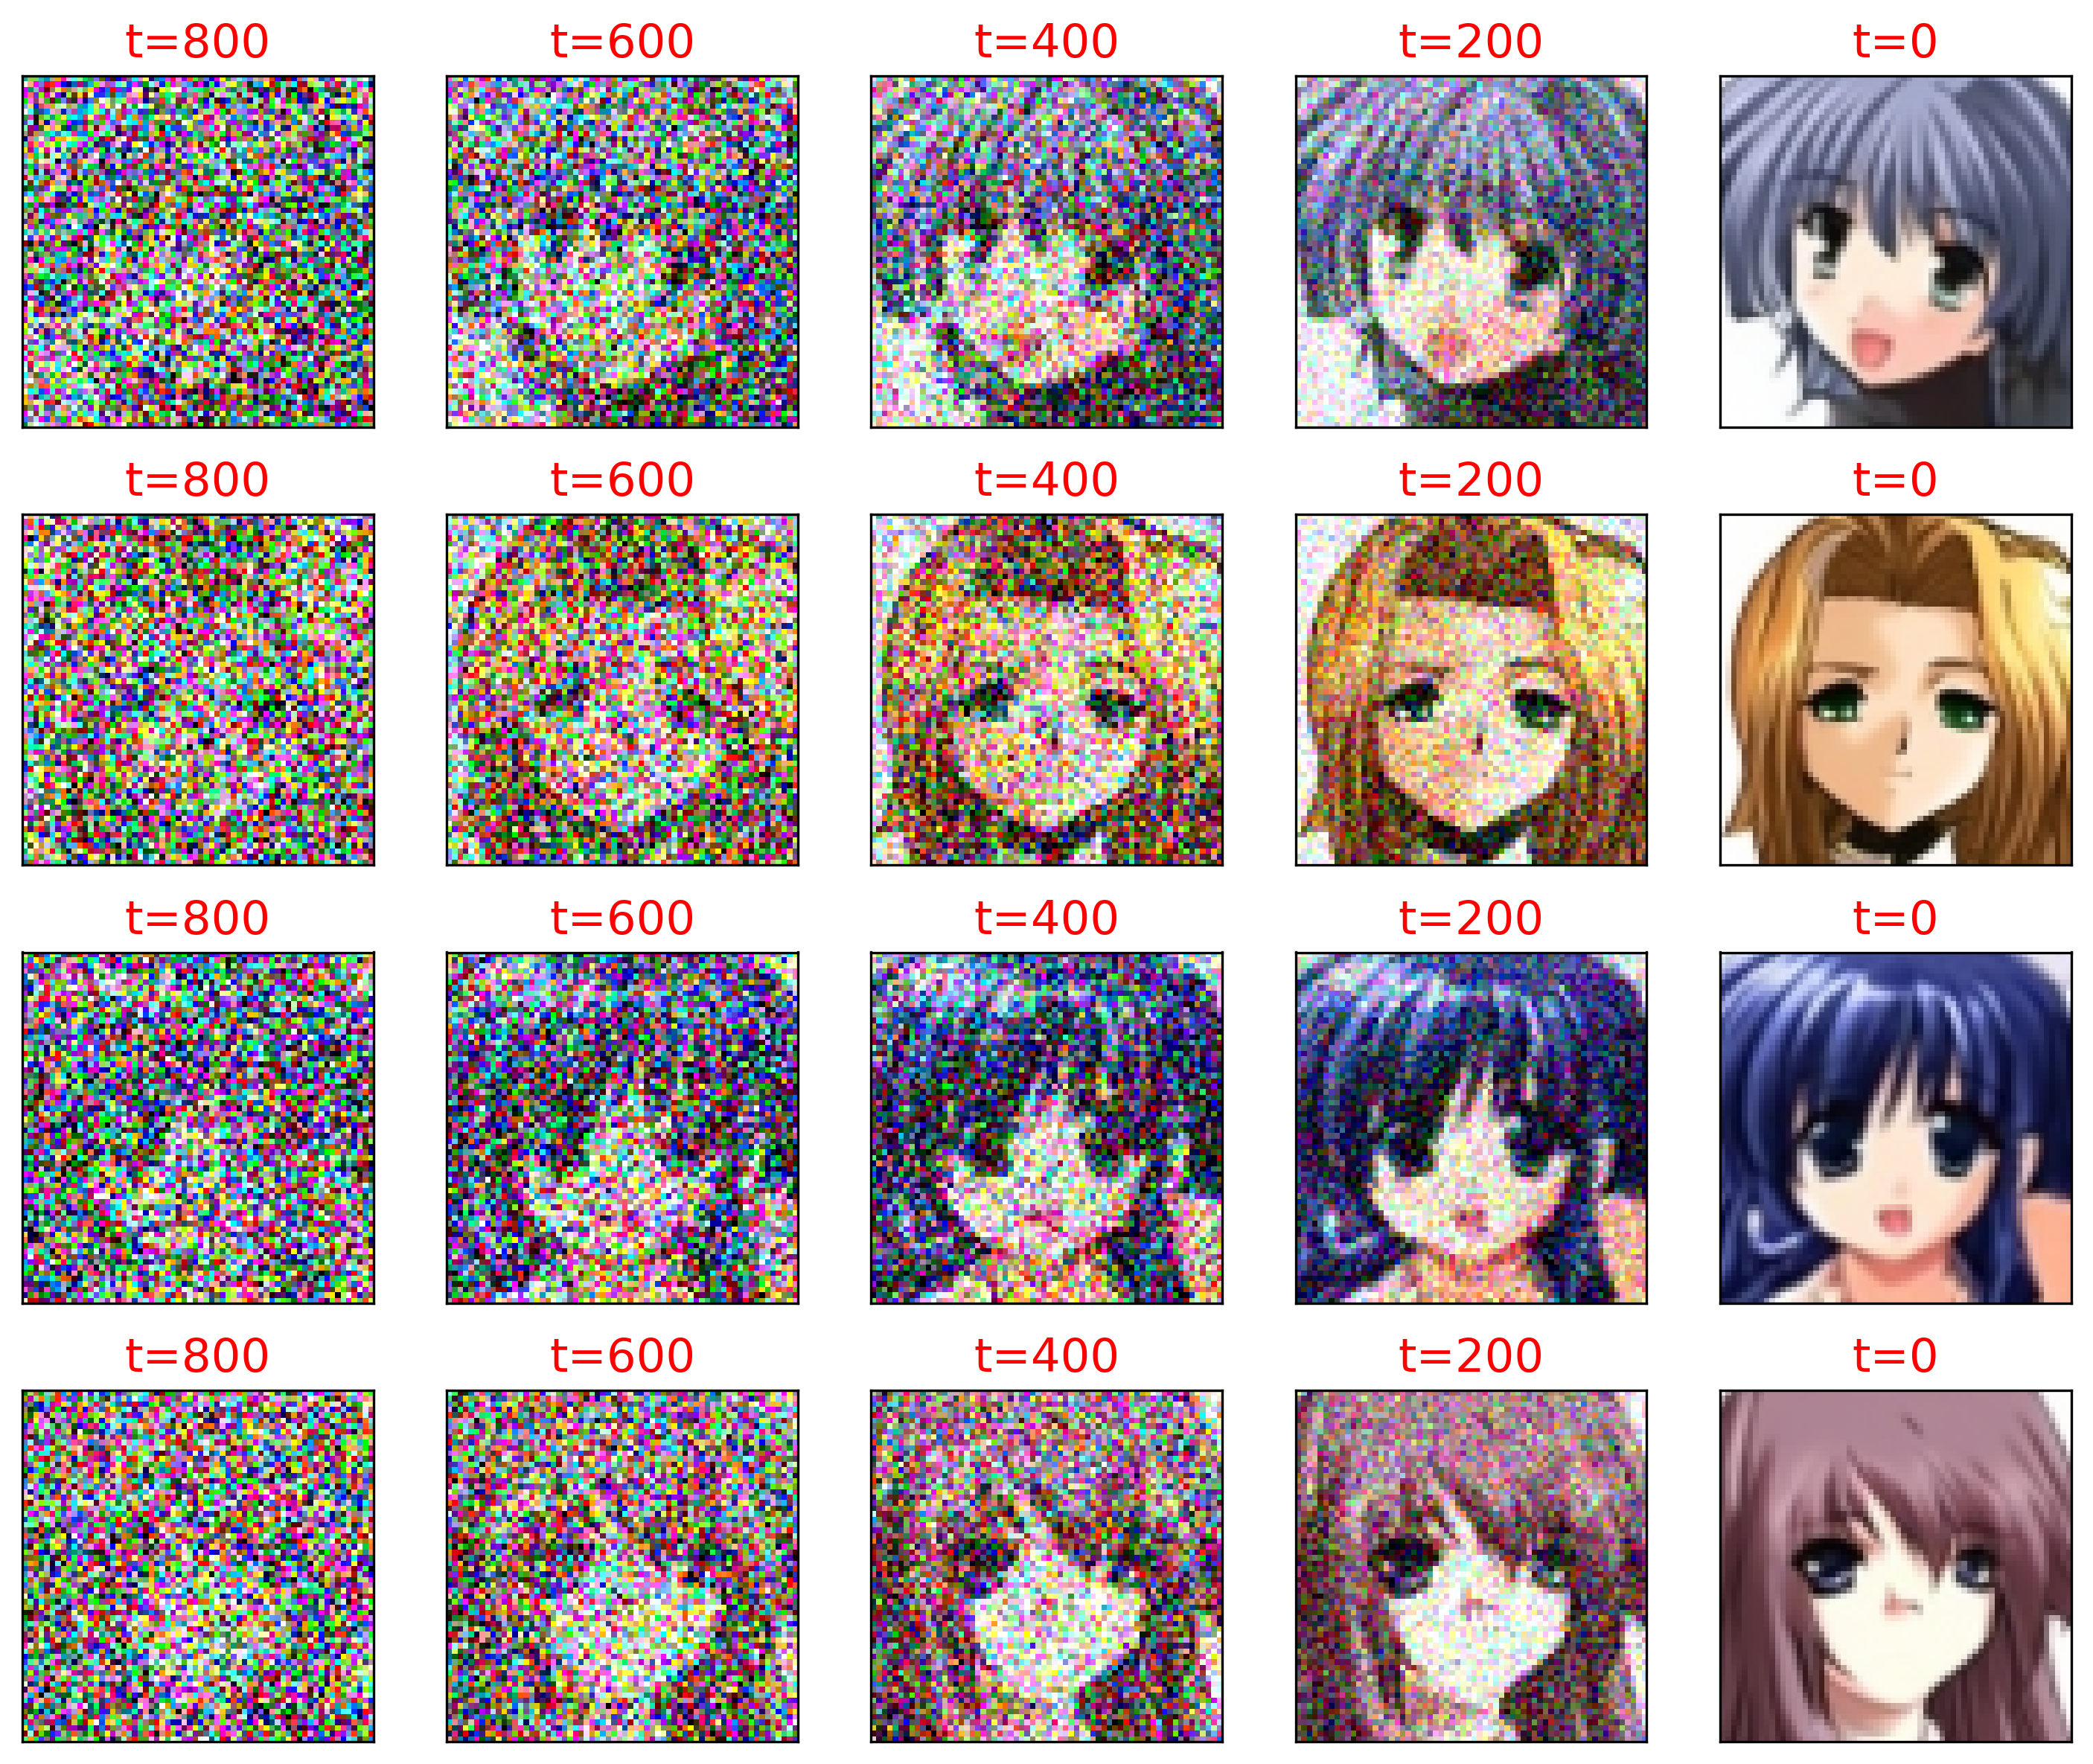

In [17]:
steps=imgs[9::10]
# select four sets out of ten
imgs20=[]
for j in [1,3,6,9]:
    for i in range(5):
        imgs20.append(steps[i][j])
# plot the 20 images in a 4 by 5 grid
plt.figure(figsize=(10,8),dpi=300)
for i in range(20):
    k=i%5
    ax = plt.subplot(4,5, i + 1)
    plt.imshow(imgs20[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.title(f't={800-200*k}',fontsize=15,c="r")
plt.show()